# Day 9 — Classification & Evaluation Metrics

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                                roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Rebuild Titanic data
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Sex_encoded'] = df['Sex'].map({'male': 0, 'female':1})
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = df.apply(lambda row: 1 if (row['SibSp'] + row['Parch'])==0 else 0, axis=1)

x = df[['Pclass', 'Sex_encoded', 'Age', 'Fare', 'IsAlone', 'FamilySize']]
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

## Part 1 — Why Accuracy Alone Lies

In [4]:
#Imagine a dataset where 90% of passengers died
#A model that predicts "everyone dies" gets 90% accuracy
#But it's completely useless - it never identifies survivors

#Check actual class balance
print(y.value_counts())
print(y.value_counts(normalize=True)) #as percentage
# Titanic is ~62% died, 38% survived — moderately imbalanced

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [5]:
#This is why we need more than accuracy

#Train logistic regression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)

#Full picture
print(classification_report(y_test, y_pred,
                            target_names=['Did not Survived', 'Survived']))

                  precision    recall  f1-score   support

Did not Survived       0.81      0.86      0.83       105
        Survived       0.78      0.72      0.75        74

        accuracy                           0.80       179
       macro avg       0.80      0.79      0.79       179
    weighted avg       0.80      0.80      0.80       179



Read the output carefully:

* Precision — when model says "survived", how often is it right?
* Recall — of all actual survivors, how many did it catch?
* F1 — balance of both
* Support — how many actual samples of each class

## Part - ROC Curve

In [6]:
# ROC curve shows tradeoff between catching survivors (recall)
# and avoiding false alarms (precision) at different thresholds

# Get probabilies instead of hard predictions
y_proba = lr.predict_proba(x_test)[:,1] #Probability of suriviving

In [7]:
# Compute ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

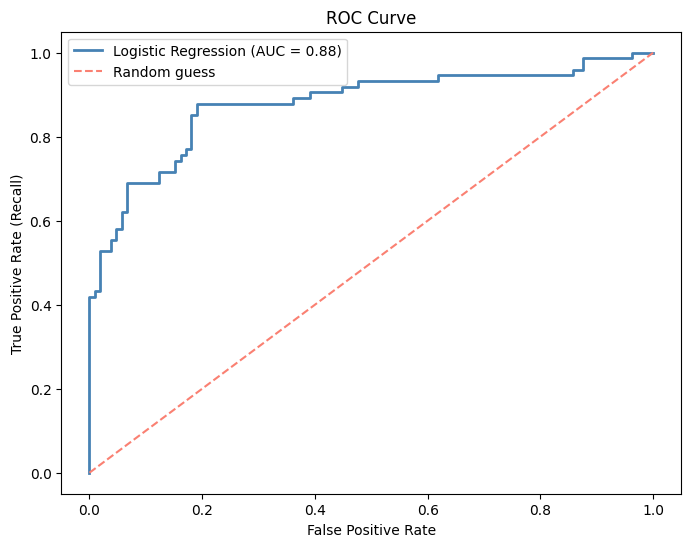

AUC Score: 0.88


In [8]:
#Plot
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'Logistic Regression (AUC = {roc_auc:.2f})')
ax.plot([0,1],[0,1], color='salmon', linestyle='--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

# AUC (Area Under Curve)
# 1.0 = perfect model
# 0.5 = Random Guessing (the diagonal line)
# 0.8+ = good model
print(f'AUC Score: {roc_auc:.2f}')

## Part 3 — Compare 3 Models Properly

In [9]:
# Define all three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

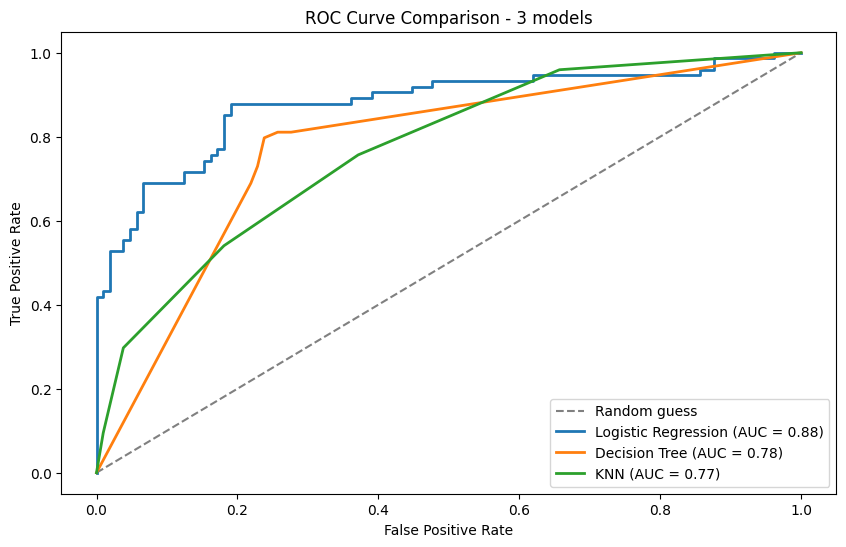

                 Model Accuracy   Auc
0  Logistic Regression   79.89%  0.88
1        Decision Tree   75.42%  0.78
2                  KNN   70.39%  0.77


In [10]:
#Train and evaluate each on the SAME test set
results = []
fig, ax = plt.subplots(figsize=(10,6))
ax.plot([0,1],[0,1], color='gray', linestyle='--', label='Random guess')

for name, model in models.items():
    #Train
    model.fit(x_train, y_train)

    #predict
    y_pred=model.predict(x_test)
    y_proba=model.predict_proba(x_test)[:,1]

    #Metics
    acc = accuracy_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    results.append({
        'Model': name,
        'Accuracy': f'{acc:.2%}',
        'Auc': f'{roc_auc:.2f}'
    })

    #Add to roc plot
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.2f})')


#Show ROC comparison
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison - 3 models')
ax.legend()
plt.show()

#Show results table
results_df = pd.DataFrame(results)
print(results_df)

## Part 4 — Exercises

In [11]:
# Exercise 1
# Look at the classification report for Logistic Regression
# Answer these in a markdown cell:
# - Which class has higher precision? Why might that be?
# - Which class has higher recall?
# - If you were building a system to identify survivors to rescue,
#   would you optimise for precision or recall? Why?

Exercise 1 Answers:
1. Did not Survived has higher precision. The dataset is already moderately imbalanced as not surviving rate is around 61% here. The model is trained by dataset where most of the outcome is didn't survived, so the model normally guessed more people didn't survived.

2. Did not Survived has higher recall too. In this dataset more people didn't survived that is why the model was able to caught this rate correctly.

3. If I were building a system to indentify survivors to rescue, I would try to optimise for recall. Because as many survivors as I can indentify correctly, as many as people I could rescue.

   Model  Accuracy
0   KNN3  0.720670
1   KNN5  0.703911
2   KNN7  0.726257
3   KNN9  0.731844
4  KNN11  0.737430


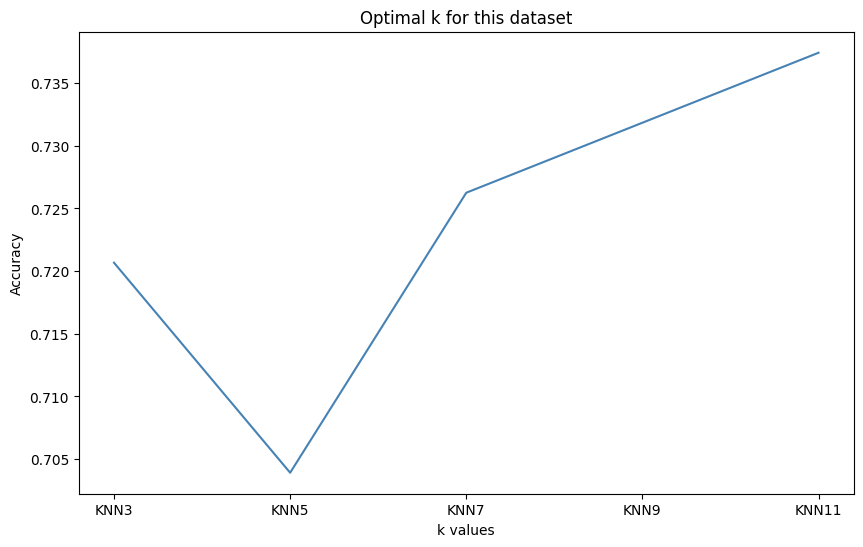

In [26]:
# Exercise 2
# KNN is sensitive to the value of n_neighbors (k)
# Try k = 3, 5, 7, 9, 11 and record accuracy for each
# Plot a line chart: x=k values, y=accuracy
# What is the optimal k for this dataset?

Kmodels = {
    'KNN3': KNeighborsClassifier(n_neighbors=3),
    'KNN5': KNeighborsClassifier(n_neighbors=5),
    'KNN7': KNeighborsClassifier(n_neighbors=7),
    'KNN9': KNeighborsClassifier(n_neighbors=9),
    'KNN11': KNeighborsClassifier(n_neighbors=11)
}

Acc_results = []
fig, ax = plt.subplots(figsize=(10,6))

for name, model in Kmodels.items():
    #Train
    model.fit(x_train, y_train)

    #predict
    y_pred=model.predict(x_test)

    #Metics
    Kacc = accuracy_score(y_test, y_pred)


    Acc_results.append({
        'Model': name,
        'Accuracy': Kacc,
    })

Acc_results_df = pd.DataFrame(Acc_results)
print(Acc_results_df)
ax.plot(Acc_results_df['Model'], Acc_results_df['Accuracy'], color='steelblue')
ax.set_xlabel('k values')
ax.set_ylabel('Accuracy')
ax.set_title('Optimal k for this dataset')

plt.show()

In [ ]:
# Exercise 3
# The Decision Tree is likely overfitting
# Train accuracy vs test accuracy tells you this:
# Print both for Decision Tree and Logistic Regression
# Hint: model.score(X_train, y_train) gives training accuracy
# A big gap between train and test = overfitting

# Exercise 4 (stretch)
# Add a Title feature to improve the model
# Go back to the raw df, extract TitleGroup as you did on Day 3
# Encode it: Mr=0, Mrs=1, Miss=2, Master=3, Other=4
# Add it to X and retrain Logistic Regression
# Does AUC improve?